In [2]:
data = palmerpenguins.load_penguins()

In [ ]:
import seaborn as sns
data = sns.load_dataset("penguins")
# Mostrar las primeras filas del DataFrame
data.head()


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


- 'bill_length_mm' - traduce a "longitud del pico en mm"
- 'bill_depth_mm' - traduce a "profundidad del pico en mm"
- 'flipper_length_mm' - 'longitud de la aleta en mm'
- 'body_mass_g' - 'masa corporal en gramos'

In [5]:
print(sns.get_dataset_names())

['anagrams', 'anscombe', 'attention', 'brain_networks', 'car_crashes', 'diamonds', 'dots', 'dowjones', 'exercise', 'flights', 'fmri', 'geyser', 'glue', 'healthexp', 'iris', 'mpg', 'penguins', 'planets', 'seaice', 'taxis', 'tips', 'titanic']


In [ ]:
import pandas as pd
# Resaltar el valor máximo en cada columna numérica
# Seleccionamos solo las columnas numéricas para resaltar
cols_numericas = data.select_dtypes(include=['number']).columns # Retorna una lista de las columnas que son numericas
data.head(10).style.highlight_max(subset=cols_numericas, axis=0, color="#1cb511")

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.100000,18.700000,181.000000,3750.000000,Male
1,Adelie,Torgersen,39.500000,17.400000,186.000000,3800.000000,Female
2,Adelie,Torgersen,40.300000,18.000000,195.000000,3250.000000,Female
3,Adelie,Torgersen,nan,nan,nan,nan,nan
4,Adelie,Torgersen,36.700000,19.300000,193.000000,3450.000000,Female
5,Adelie,Torgersen,39.300000,20.600000,190.000000,3650.000000,Male
6,Adelie,Torgersen,38.900000,17.800000,181.000000,3625.000000,Female
7,Adelie,Torgersen,39.200000,19.600000,195.000000,4675.000000,Male
8,Adelie,Torgersen,34.100000,18.100000,193.000000,3475.000000,nan
9,Adelie,Torgersen,42.000000,20.200000,190.000000,4250.000000,nan


In [13]:
# O poner barras de color según la magnitud
data.head(10).style.bar(subset=['body_mass_g'], color='#d65f5f')

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.100000,18.700000,181.000000,3750.000000,Male
1,Adelie,Torgersen,39.500000,17.400000,186.000000,3800.000000,Female
2,Adelie,Torgersen,40.300000,18.000000,195.000000,3250.000000,Female
3,Adelie,Torgersen,nan,nan,nan,nan,nan
4,Adelie,Torgersen,36.700000,19.300000,193.000000,3450.000000,Female
5,Adelie,Torgersen,39.300000,20.600000,190.000000,3650.000000,Male
6,Adelie,Torgersen,38.900000,17.800000,181.000000,3625.000000,Female
7,Adelie,Torgersen,39.200000,19.600000,195.000000,4675.000000,Male
8,Adelie,Torgersen,34.100000,18.100000,193.000000,3475.000000,nan
9,Adelie,Torgersen,42.000000,20.200000,190.000000,4250.000000,nan


In [ ]:
# Que tipo de datos tenemos en el DataFrame
data.dtypes # dtypes, es un metodo de los dataframes de pandas, nos devuelve una serie con el nombre de las columnas y su tipo de dato
# Las variables tipo objeto por lo general son variables categóricas, como el sexo, la especie, etc.

species               object
island                object
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
dtype: object

In [15]:
# Cuantas variables de cada tipo tenemos
data.dtypes.value_counts()

float64    4
object     3
Name: count, dtype: int64

In [16]:
# Cuantas variables y observaciones tenemos en el conjunto de datos (dataframe) 
data.shape # Nos devuelve una tupla con (filas, columnas)

(344, 7)

In [ ]:
# Existen valores nulos en la data?

data.isnull()  ### Importante: Devuelve un DataFrame de True / False que permite otros analisis

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,True,True,True,True,True
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
339,False,False,True,True,True,True,True
340,False,False,False,False,False,False,False
341,False,False,False,False,False,False,False
342,False,False,False,False,False,False,False


In [ ]:
# Permite saber si existe al menos un valor nulo en alguna columna
data.isnull().any()

In [ ]:
# Permite saber cuántos valores nulos hay en cada columna
data.isnull().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

In [ ]:
from IPython.display import display   #### Permite mostrar el estilo tablas de pandas en Jupyter Notebooks
# Cuales filas posee valores nulos en la data?
display(data[data.isnull().any(axis=1)]) # Indexación booleana de Pandas (no es list comprehension) (usa C internamente segun|)
print(f"Total de filas con nulos: {data.isnull().any(axis=1).sum()}")
print(f"Indices de filas con nulos: {data[data.isnull().any(axis=1)].index.tolist()}")
# Donde:
# .any(axis=1) -> Revisa fila por fila si existe al menos un valor nulo (True/False)
# .sum() -> Suma los valores True (1) para obtener el total de filas con nulos
# .tolist() -> Convierte el objeto tipo índice (de las filas con nulos) en una lista de Python

# ESTA FORMA NO ES RECOMENDABLE porque es lenta para dataframes grandes
# import numpy as np
# rows_with_nulls = [
#     row for _, row in data.iterrows()
#     if row.isnull().any()
# ]
# Donde:
# .iterrows() -> Permite iterar fila por fila en un DataFrame (lento)
# row.isnull().any() -> Revisa si en la fila existe al menos un valor nulo (True/False)



,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN
10,Adelie,Torgersen,37.8,17.1,186.0,3300.0,NaN
11,Adelie,Torgersen,37.8,17.3,180.0,3700.0,NaN
47,Adelie,Dream,37.5,18.9,179.0,2975.0,NaN
246,Gentoo,Biscoe,44.5,14.3,216.0,4100.0,NaN
286,Gentoo,Biscoe,46.2,14.4,214.0,4650.0,NaN
324,Gentoo,Biscoe,47.3,13.8,216.0,4725.0,NaN
336,Gentoo,Biscoe,44.5,15.7,217.0,4875.0,NaN


Total de filas con nulos: 11
Indices de filas con nulos: [3, 8, 9, 10, 11, 47, 246, 286, 324, 336, 339]
Indices de filas con nulos: Index([3, 8, 9, 10, 11, 47, 246, 286, 324, 336, 339], dtype='int64')


In [54]:
# uso de .melt() para transformar un DataFrame de formato ancho a formato largo
# La función .melt() sirve para "des-pivotar" una tabla. (fusionar por ej dos tablas,romper la 2FN)
# En términos sencillos, convierte una tabla "ancha" (muchas columnas)
# en una tabla "larga", donde los valores se apilan en filas.
# Por tanto, es una herramienta clave en la fase de Transformación de datos (ETL),
# ya que permite normalizar estructuras que no son fáciles de analizar (en su forma ancha) o de visualizar en su formato original.
# En el formato largo:
# - Cada variable se representa en una columna
# - Cada observación o registro se representa en una fila
# Es común que el formato largo repita valores (rompa la 2ª Forma Normal),
# lo cual NO es un problema en análisis de datos.
# Este enfoque es similar a lo que hacen herramientas como Power BI,
# tablas dinámicas o motores analíticos, donde se prioriza el análisis sobre la normalización estricta de bases de datos relacionales.

data_melted = pd.melt(
    data,
    id_vars=['species', 'island'],   # columnas que se mantienen "fijas" como identificadores
    value_vars=['bill_length_mm', 'body_mass_g'],  # columnas a "apilar" (las que me interesa)
    var_name='measurement',          # nombre de la columna de variables en la cual se apilarán los nombres originales de las columnas
    value_name='value'               # nombre de la columna de valores
)
display(data_melted.head(348))
# Cuantas filas posee este nuevo DataFrame?
print(f"Total de filas en data_melted: {data_melted.shape[0]}")  # shape[0] devuelve el número de filas



,species,island,measurement,value
0,Adelie,Torgersen,bill_length_mm,39.1
1,Adelie,Torgersen,bill_length_mm,39.5
2,Adelie,Torgersen,bill_length_mm,40.3
3,Adelie,Torgersen,bill_length_mm,NaN
4,Adelie,Torgersen,bill_length_mm,36.7
...,...,...,...,...
343,Gentoo,Biscoe,bill_length_mm,49.9
344,Adelie,Torgersen,body_mass_g,3750.0
345,Adelie,Torgersen,body_mass_g,3800.0
346,Adelie,Torgersen,body_mass_g,3250.0


Total de filas en data_melted: 688


In [20]:
# Otras formas de hacerlo, si lo me interesa body_mass_g
data[data['body_mass_g'].isnull()]

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN


El grafico muestra la proporción de valores nulos (True) y no nulos (False) por columna. Donde la cantidad de valores nulos es muy baja en comparación con los no nulos.


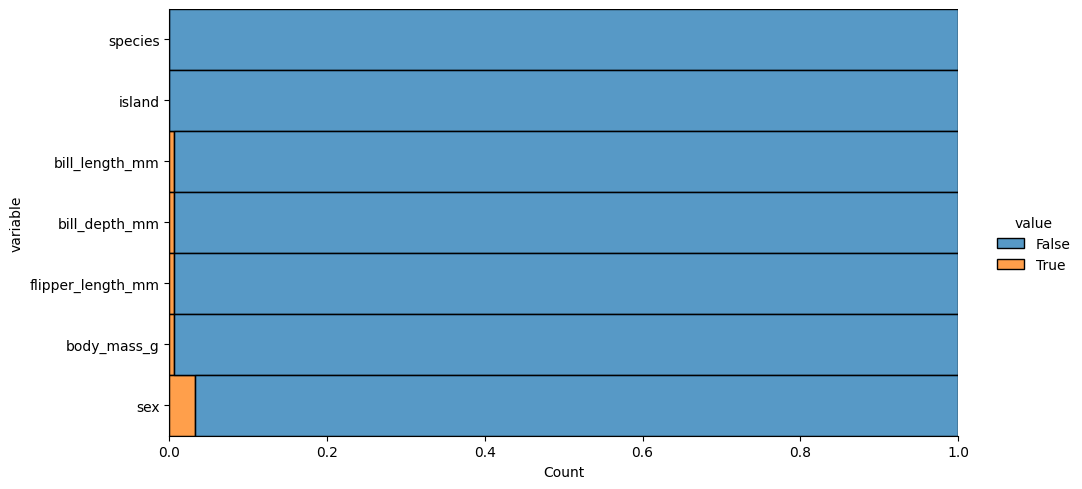

In [ ]:
(data.isnull()
.melt() # apilo todas las columnas en formato largo
.pipe(  # permite encadenar operaciones
    lambda df: (
        sns.displot(
            data = df,
            y = 'variable',
            hue = 'value',
            multiple = 'fill',
            aspect = 2,
        )
    )
)
)
print("El grafico muestra la proporción de valores nulos (True) y no nulos (False) por columna. Donde la cantidad de valores nulos es muy baja en comparación con los no nulos.")

In [ ]:
# .transpose() (.T)
# Intercambia filas por columnas y columnas por filas.
# Las columnas pasan a ser índices y los índices pasan a ser columnas.

# No modifica los datos en sí, solo cambia la orientación del DataFrame.
# Es una operación de vista / reestructuración, no de limpieza.

# Muy útil para:
# - Inspección rápida de datos
# - Visualizar muchas columnas en pocas filas
# - Comparar valores de un mismo registro
# - Analizar resultados de estadísticas (.describe(), .agg())
# REALMETNE no se usa para eliminar registros, transformar o limpiar datos como tal.
data.head(10).transpose()

,0,1,2,3,4,5,6,7,8,9
species,Adelie,Adelie,Adelie,Adelie,Adelie,Adelie,Adelie,Adelie,Adelie,Adelie
island,Torgersen,Torgersen,Torgersen,Torgersen,Torgersen,Torgersen,Torgersen,Torgersen,Torgersen,Torgersen
bill_length_mm,39.1,39.5,40.3,NaN,36.7,39.3,38.9,39.2,34.1,42.0
bill_depth_mm,18.7,17.4,18.0,NaN,19.3,20.6,17.8,19.6,18.1,20.2
flipper_length_mm,181.0,186.0,195.0,NaN,193.0,190.0,181.0,195.0,193.0,190.0
body_mass_g,3750.0,3800.0,3250.0,NaN,3450.0,3650.0,3625.0,4675.0,3475.0,4250.0
sex,Male,Female,Female,NaN,Female,Male,Female,Male,NaN,NaN


In [ ]:
# Conocer estadísticos descriptivos de las columnas numéricas.
# Es visualmente más claro con .transpose() 
# Como media, mediana, desviación estándar, valores mínimos y máximos, y percentiles.
data.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
bill_length_mm,342.0,43.921930,5.459584,32.1,39.225,44.45,48.5,59.6
bill_depth_mm,342.0,17.151170,1.974793,13.1,15.600,17.30,18.7,21.5
flipper_length_mm,342.0,200.915205,14.061714,172.0,190.000,197.00,213.0,231.0
body_mass_g,342.0,4201.754386,801.954536,2700.0,3550.000,4050.00,4750.0,6300.0


<Axes: >

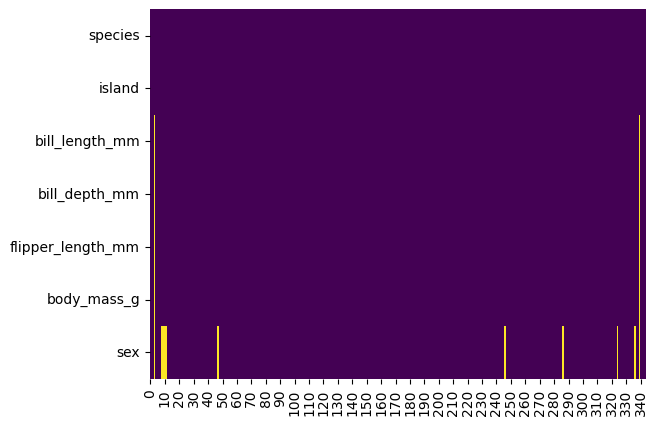

In [ ]:
# Conocer que registros tienen valores nulos en el DataFrame segun un un mapa de calor
(
    data
    .isnull()
    .transpose()
    .pipe(
        lambda df: (
            sns.heatmap(
                df,
                cbar=False, # quitar barra de colores
                cmap='viridis', # escala de colores
                # yticklabels=True, # mostrar etiquetas en eje y

            )
        )
    )

)

In [ ]:
# ELIMINAR los registros con valores nulos PERO antes reemplazar los nulos de sex por un valor como "no_definido"
# Creamos una copia profunda de los datos
data_clean = data.copy()
# Llenamos los nulos de la columna 'sex' con una nueva categoría
data_clean['sex'] = data_clean['sex'].fillna('not-defined')
#Aunque los algoritmos modernos de Machine Learning (como XGBoost) saben manejar nulos por sí solos, muchas funciones estadísticas o de gráficas ignorarán filas con null o darán error si no las manejas antes.
# 1. Eliminar si no hay medidas (los datos realmente inservibles)
# por tanto afectar variables con valores numericos como ['body_mass_g', 'bill_length_mm']
variables_num = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
data_clean = data_clean.dropna(subset=variables_num)
# Ahora puedes comparar ambos
print(f"Filas originales: {len(data)}")
print(f"Filas limpias: {len(data_clean)}")

Filas originales: 344
Filas limpias: 342
